In [1]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [2]:
matched = Path("/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks/alerce_match_partial.csv")
matched = pd.read_csv(matched)

lsst_zip = Path(
    "/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip"
)

In [3]:
head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"

with ZipFile(lsst_zip, "r") as archive:
    # Read and decompress HEAD file
    head_bytes = gzip.decompress(archive.read(head_name))

    with fits.open(BytesIO(head_bytes), memmap=False) as hdul:
        head_data = hdul[1].data.copy()

    # Read and decompress PHOT file
    phot_bytes = gzip.decompress(archive.read(phot_name))

    with fits.open(BytesIO(phot_bytes), memmap=False) as hdul:
        phot_data = hdul[1].data.copy()

In [7]:
# Crossmatch function
target_snid = "dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"

all_snids = np.char.strip(
    np.asarray(head_data["SNID"]).astype(str)
)

matches = np.where(all_snids == target_snid)[0]

print("Matches:", matches)
print(matched.columns.tolist())
display(matched.head())

Matches: [43571]
['SNID', 'oid', 'sep_arcsec', 'p_SN', 'classifier_version']


,SNID,oid,sep_arcsec,p_SN,classifier_version
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,3.138535e+17,0.004703,0.002284,202.0
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,3.138535e+17,0.005537,0.001532,202.0
2,1ee3563b-4982-460e-8a6f-f609d50f62c9,3.138710e+17,0.007144,0.019884,202.0
3,23af3b06-9c88-44d8-a6c2-39a062326bbf,3.138535e+17,0.006170,0.003808,202.0
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,3.138754e+17,0.019361,0.020532,202.0


In [8]:
# Position of this object in the HEAD table
idx = matches[0]

# All object-level information
head_row = head_data[idx]

# Locate this object's observations in the PHOT table
start = int(head_row["PTROBS_MIN"]) - 1
stop = int(head_row["PTROBS_MAX"])

# Extract all photometric observations for this object
lightcurve = phot_data[start:stop].copy()

print("HEAD row index:", idx)
print("PHOT rows:", start, "to", stop - 1)
print("Number of observations:", len(lightcurve))

HEAD row index: 43571
PHOT rows: 233375 to 233463
Number of observations: 89


In [9]:
head_df = pd.DataFrame(
    {
        column: [head_row[column]]
        for column in head_data.names
    }
)

display(head_df)

,SNID,NAME_IAUC,NAME_TRANSIENT,FAKE,MASK_FLUXCOR_SNANA,RA,DEC,PIXSIZE,NXPIX,NYPIX,...,PRIVATE(NOBS_AFTER_COADD),PRIVATE(RATIO_NOBS_COADD),PRIVATE(NOBS_GARBAGE),PRIVATE(N_NITE_DETECT_u),PRIVATE(N_NITE_DETECT_g),PRIVATE(N_NITE_DETECT_r),PRIVATE(N_NITE_DETECT_i),PRIVATE(N_NITE_DETECT_z),PRIVATE(N_NITE_DETECT_y),PRIVATE(N_NITE_DETECT_ANY_BAND)
0,dbce04ab-1a55-4d43-abb2-b24a53e4fb2a,UNKNOWN,313761043604045880,0,0,61.96482,-48.713443,0.199598,4072,4000,...,89.0,0.120924,0.0,0.0,23.0,18.0,28.0,20.0,0.0,48.0


In [11]:
print("Target SNID:", target_snid)
print("HEAD SNID:", str(head_row["SNID"]).strip())

print("PTROBS_MIN:", head_row["PTROBS_MIN"])
print("PTROBS_MAX:", head_row["PTROBS_MAX"])
print("HEAD NOBS:", head_row["NOBS"])
print("Extracted observations:", len(lightcurve))

assert len(lightcurve) == int(head_row["NOBS"]), (
    f"Expected {head_row['NOBS']} observations, "
    f"but extracted {len(lightcurve)}"
)

print("\nPHOT columns:")
print(lightcurve.dtype.names)

Target SNID: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
HEAD SNID: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
PTROBS_MIN: 233376
PTROBS_MAX: 233464
HEAD NOBS: 89
Extracted observations: 89

PHOT columns:
('MJD', 'BAND', 'DETNUM', 'IMGNUM', 'FIELD', 'PHOTFLAG', 'PHOTPROB', 'FLUXCAL', 'FLUXCALERR', 'PSF_SIG1', 'PSF_SIG2', 'PSF_RATIO', 'SKY_SIG', 'SKY_SIG_T', 'RDNOISE', 'ZEROPT', 'ZEROPT_ERR', 'TEXPOSE', 'GAIN', 'XPIX', 'YPIX')


In [13]:
def clean_band(value):
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8", errors="ignore")

    return str(value).strip().strip("\x00")


lightcurve_df = pd.DataFrame({
    "MJD": np.array(
        lightcurve["MJD"],
        dtype=np.float64,
        copy=True,
    ),
    "FLUXCAL": np.array(
        lightcurve["FLUXCAL"],
        dtype=np.float64,
        copy=True,
    ),
    "FLUXCALERR": np.array(
        lightcurve["FLUXCALERR"],
        dtype=np.float64,
        copy=True,
    ),
    "BAND": [
        clean_band(value)
        for value in lightcurve["BAND"]
    ],
})

display(lightcurve_df.head())

,MJD,FLUXCAL,FLUXCALERR,BAND
0,61003.3367,1007.599976,170.880005,r
1,61004.3020,2133.399902,100.580002,r
2,61006.2260,-18166.000000,201.660004,i
3,61009.0575,9390.700195,247.149994,z
4,61012.2809,19434.000000,416.899994,z


In [14]:
print("HEAD NOBS:", int(head_row["NOBS"]))
print("Extracted rows:", len(lightcurve_df))

assert len(lightcurve_df) == int(head_row["NOBS"])

print("Bands:", np.unique(lightcurve_df["BAND"]))

print(
    "MJD range:",
    lightcurve_df["MJD"].min(),
    "to",
    lightcurve_df["MJD"].max(),
)

print(
    "FLUXCAL range:",
    lightcurve_df["FLUXCAL"].min(),
    "to",
    lightcurve_df["FLUXCAL"].max(),
)

display(
    lightcurve_df
    .groupby("BAND")
    .agg(
        n_observations=("MJD", "size"),
        min_mjd=("MJD", "min"),
        max_mjd=("MJD", "max"),
        min_flux=("FLUXCAL", "min"),
        max_flux=("FLUXCAL", "max"),
    )
)

HEAD NOBS: 89
Extracted rows: 89
Bands: ['g' 'i' 'r' 'z']
MJD range: 61003.3367 to 61230.4212
FLUXCAL range: -18166.0 to 135290.0


,n_observations,min_mjd,max_mjd,min_flux,max_flux
BAND,,,,,
g,23,61019.2897,61227.4149,26589.000000,82421.0
i,28,61006.2260,61227.4194,-18166.000000,114580.0
r,18,61003.3367,61102.1170,1007.599976,114060.0
z,20,61009.0575,61230.4212,9390.700195,135290.0


In [15]:
valid = (
    np.isfinite(lightcurve_df["MJD"])
    & np.isfinite(lightcurve_df["FLUXCAL"])
    & np.isfinite(lightcurve_df["FLUXCALERR"])
    & (lightcurve_df["FLUXCALERR"] > 0)
)

lsst_lc = (
    lightcurve_df.loc[valid]
    .sort_values("MJD")
    .reset_index(drop=True)
)

print(
    f"Retained {len(lsst_lc)} of "
    f"{len(lightcurve_df)} observations"
)

Retained 89 of 89 observations


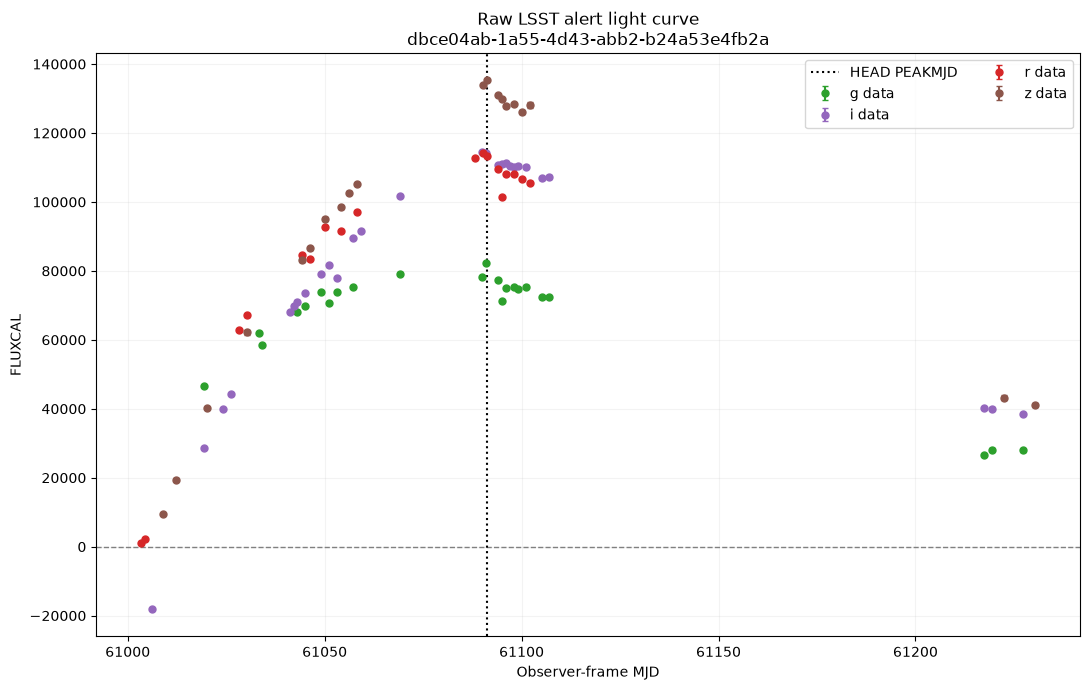

In [16]:
band_colours = {
    "u": "#7B2CBF",
    "g": "#2CA02C",
    "r": "#D62728",
    "i": "#9467BD",
    "z": "#8C564B",
    "y": "#BCBD22",
}

fig, ax = plt.subplots(figsize=(11, 7))

for band in sorted(lsst_lc["BAND"].unique()):
    band_data = lsst_lc[
        lsst_lc["BAND"] == band
    ]

    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        ms=5,
        capsize=2,
        color=band_colours.get(band, "black"),
        label=f"{band} data",
    )

ax.axhline(
    0,
    color="0.5",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    float(head_row["PEAKMJD"]),
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="HEAD PEAKMJD",
)

ax.set_xlabel("Observer-frame MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(
    f"Raw LSST alert light curve\n{target_snid}"
)
ax.legend(ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

### Fit Foundation object

In [39]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [45]:
project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "Foundation_DR1.zip"

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from pathlib import Path
from bayesn import SEDmodel

snid = "ASASSN-15so"

sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

z_quantiles = jnp.linspace(0.001, 0.30, 101)

model = SEDmodel(load_model="T21_model")

samples, sn_props = model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=z_quantiles,
    chain_method="parallel",
)


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.12      0.05      0.12      0.03      0.20    312.85      1.01
          Ds[0]     32.81      0.05     32.81     32.73     32.89    342.44      1.01
 eps_tform[0,0]      0.63      0.57      0.65     -0.30      1.61    670.75      1.01
 eps_tform[0,1]      1.05      0.49      1.06      0.27      1.81    722.90      1.00
 eps_tform[0,2]      1.34      0.50      1.33      0.56      2.27    862.89      1.00
 eps_tform[0,3]     -0.02      0.64     -0.02     -1.06      1.05    772.42      1.00
 eps_tform[0,4]     -1.37      0.61     -1.37     -2.31     -0.39    483.38      1.00
 eps_tform[0,5]     -0.28      0.53     -0.27     -1.14      0.58    750.38      1.00
 eps_tform[0,6]      0.14      0.59      0.13     -0.74      1.21    436.46      1.00
 eps_tform[0,7]     -0.19      0.42     -0.20     -0.97      0.40    380.95      1.01
 eps_tform[0,8]      0.67      0.50      0.69     -0.

In [47]:
# Get flux from chains

meta, tables = sncosmo.read_snana_ascii(
    str(sn_file),
    default_tablename="OBS",
)

lc = tables["OBS"].to_pandas().sort_values("MJD")

plot_samples = dict(samples)
plot_samples.setdefault("mu", plot_samples["Ds"])
plot_samples.setdefault(
    "delM",
    np.zeros_like(plot_samples["Ds"]),
)

model.peak_mjds = np.array([float(meta["SEARCH_PEAKMJD"])])
model.ebv = np.array([float(meta["MWEBV"])])

bands = [["g_PS1", "r_PS1", "i_PS1", "z_PS1"]]

model_mjd, model_flux, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                      | 0/1 [00:00<?, ?it/s]



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:15<00:00, 15.73s/it]


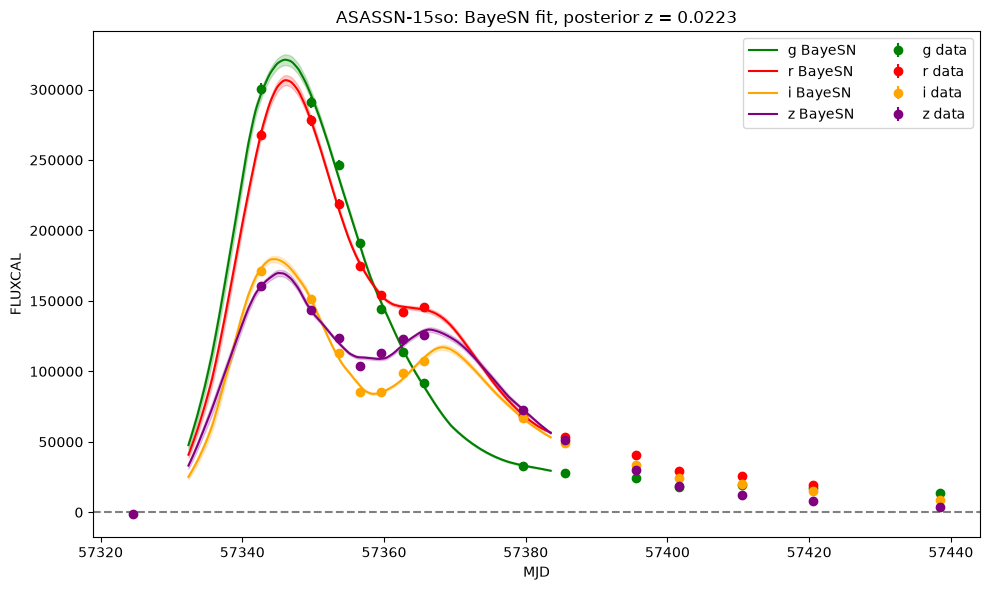

In [48]:
colours = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for i, band in enumerate(["g", "r", "i", "z"]):
    observed = lc[lc["FLT"].astype(str).str.strip() == band]

    ax.errorbar(
        observed["MJD"],
        observed["FLUXCAL"],
        yerr=observed["FLUXCALERR"],
        fmt="o",
        color=colours[band],
        label=f"{band} data",
    )

    ax.plot(
        model_mjd[0],
        model_flux[0, i],
        color=colours[band],
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        model_mjd[0],
        model_flux[0, i] - model_std[0, i],
        model_flux[0, i] + model_std[0, i],
        color=colours[band],
        alpha=0.2,
    )

z = np.asarray(samples["z"]).reshape(-1)

ax.axhline(0, color="grey", linestyle="--")
ax.set(
    xlabel="MJD",
    ylabel="FLUXCAL",
    title=f"{snid}: BayeSN fit, posterior z = {np.median(z):.4f}",
)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

### LSST data

In [50]:
target_snid = "dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"
head_row = head_data[
    np.char.strip(head_data["SNID"].astype(str)) == target_snid
][0]

def get_lightcurve(head_row, phot_table):
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])

    lc = pd.DataFrame(
        phot_table[start:stop]
    )

    # Convert byte strings such as b"g" into normal strings
    lc["BAND"] = (
        lc["BAND"]
        .str.decode("utf-8")
        .str.strip()
        if lc["BAND"].dtype == object
        else lc["BAND"].astype(str).str.strip()
    )

    return lc
    
target_lc = get_lightcurve(head_row, phot_data)

In [51]:
target_snid = "dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"

snids = np.char.strip(
    head_data["SNID"].astype(str)
)

head_row = head_data[snids == target_snid][0]

target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))
display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 89


,MJD,BAND,FLUXCAL,FLUXCALERR
0,61003.3367,r,1007.599976,170.880005
1,61004.3020,r,2133.399902,100.580002
2,61006.2260,i,-18166.000000,201.660004
3,61009.0575,z,9390.700195,247.149994
4,61012.2809,z,19434.000000,416.899994


In [52]:
# Keep valid measurements
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
].copy()

# Remove possible "LSST_" prefix
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

print(target_lc["BAND"].value_counts())

BAND
i    28
g    23
z    20
r    18
Name: count, dtype: int64


In [55]:
import jax.numpy as jnp
from bayesn import SEDmodel

# Use the highest-SNR observation as an approximate peak
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])

import numpy as np
import jax.numpy as jnp
from bayesn import SEDmodel

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"]).astype(str)

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0.001, 1.0, 101)

model = SEDmodel(load_model="T21_model")

samples, props = model.fit(
    t,
    flux,
    flux_err,
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.11      0.06      0.09      0.07      0.21      2.00   2692.94
          Ds[0]     38.76      0.70     38.71     37.73     39.76      2.10      8.66
 eps_tform[0,0]      0.22      0.26      0.29     -0.20      0.51      2.00   9160.20
 eps_tform[0,1]      0.02      0.32     -0.00     -0.38      0.49      2.00   8956.51
 eps_tform[0,2]      0.30      0.20      0.31      0.01      0.58      2.00   5752.54
 eps_tform[0,3]      0.19      0.38      0.12     -0.24      0.77      2.00  11840.82
 eps_tform[0,4]      0.00      0.23      0.09     -0.38      0.20      2.00   5621.79
 eps_tform[0,5]     -0.08      0.34     -0.12     -0.52      0.44      2.00  11135.83
 eps_tform[0,6]      0.11      0.25      0.02     -0.13      0.53      2.00   6903.12
 eps_tform[0,7]      0.10      0.08      0.11     -0.01      0.20      2.00   2307.78
 eps_tform[0,8]      0.16      0.09      0.18      0.

In [56]:
z_samples = np.asarray(samples["z"]).reshape(-1)

print("Posterior median z:", np.median(z_samples))
print("68% interval:", np.percentile(z_samples, [16, 84]))


Posterior median z: 0.40595928579163665
68% interval: [0.37191514 0.79712603]


In [57]:
plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(plot_samples["Ds"])

# Tell the model about this object's metadata
model.peak_mjds = np.array(
    [float(head_row["PEAKMJD"])]
)

model.ebv = np.array(
    [float(head_row["MWEBV"])]
)

observed_bands = [
    band for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                      | 0/1 [00:00<?, ?it/s]



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.23s/it]


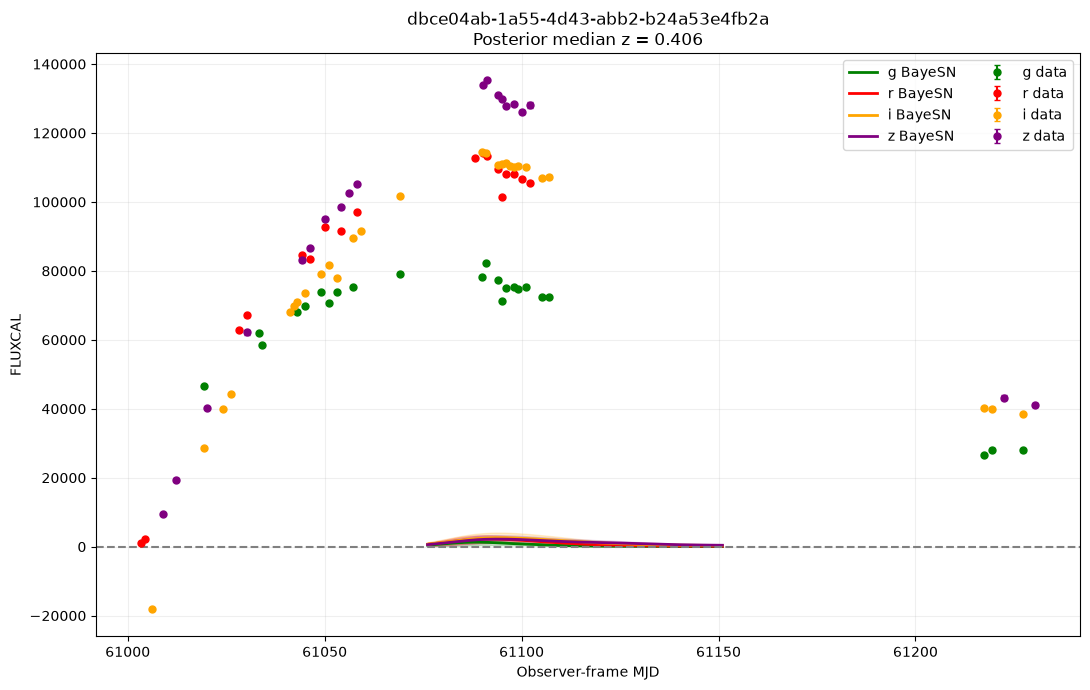

In [58]:
colours = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}

fig, ax = plt.subplots(figsize=(11, 7))

for band_index, band in enumerate(observed_bands):
    use = filters == band
    colour = colours[band]

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colour,
        label=f"{band} data",
        zorder=3,
    )

    fitted_flux = model_mean[0, band_index]
    fitted_std = model_std[0, band_index]

    ax.plot(
        model_mjd[0],
        fitted_flux,
        color=colour,
        linewidth=2,
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        model_mjd[0],
        fitted_flux - fitted_std,
        fitted_flux + fitted_std,
        color=colour,
        alpha=0.18,
    )

z_median = np.median(
    np.asarray(samples["z"]).reshape(-1)
)

ax.axhline(0, color="grey", linestyle="--")
ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=f"{target_snid}\nPosterior median z = {z_median:.3f}",
)
ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [59]:
print("Observed MJD range:", t.min(), "to", t.max())
print("Model MJD range:", model_mjd[0].min(), "to", model_mjd[0].max())

print("Observed flux range:", flux.min(), "to", flux.max())
print("Model flux range:", model_mean.min(), "to", model_mean.max())

Observed MJD range: 61003.3367 to 61230.4212
Model MJD range: 61076.12022382599 to 61150.987854696046
Observed flux range: -18166.0 to 135290.0
Model flux range: 37.01107388225982 to 2585.8293410218153


In [60]:
for band in observed_bands:
    use = filters == band

    print(f"\n{band}")
    print("N points:", use.sum())
    print("Flux range:", flux[use].min(), flux[use].max())
    print("Median flux:", np.median(flux[use]))
    print("Positive fraction:", np.mean(flux[use] > 0))
    print("SNR > 3:", np.sum(flux[use] / flux_err[use] > 3))


g
N points: 23
Flux range: 26589.0 82421.0
Median flux: 72475.0
Positive fraction: 1.0
SNR > 3: 23

r
N points: 18
Flux range: 1007.5999755859375 114060.0
Median flux: 99146.5
Positive fraction: 1.0
SNR > 3: 18

i
N points: 28
Flux range: -18166.0 114580.0
Median flux: 85579.0
Positive fraction: 0.9642857142857143
SNR > 3: 27

z
N points: 20
Flux range: 9390.7001953125 135290.0
Median flux: 100529.0
Positive fraction: 1.0
SNR > 3: 20
